In [1]:
# importing the modules 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
# INPUTS - enter prediction file, AA sequences here
#ESM-1bv sequence-only
df_US_L = pd.read_csv('/Users/juliemcdonald/Documents/Shoulders_lab/Rubisco_data/heatmap_testing/input_files/US.csv')

#ESM-IF1 1RLC input
df_1rlc_L = pd.read_csv('/Users/juliemcdonald/Documents/Shoulders_lab/Rubisco_data/heatmap_testing/input_files/1rlc.csv')

#ESM-IF1 4RUB input
df_4rub_L = pd.read_csv('/Users/juliemcdonald/Documents/Shoulders_lab/Rubisco_data/heatmap_testing/input_files/4rub.csv')

#NtRbcL sequence
rbcL_seq='MSPQTETKASVGFKAGVKEYKLTYYTPEYQTKDTDILAAFRVTPQPGVPPEEAGAAVAAESSTGTWTTVWTDGLTSLDRYKGRCYRIERVVGEKDQYIAYVAYPLDLFEEGSVTNMFTSIVGNVFGFKALRALRLEDLRIPPAYVKTFQGPPHGIQVERDKLNKYGRPLLGCTIKPKLGLSAKNYGRAVYECLRGGLDFTKDDENVNSQPFMRWRDRFLFCAEALYKAQAETGEIKGHYLNATAGTCEEMIKRAVFARELGVPIVMHDYLTGGFTANTSLAHYCRDNGLLLHIHRAMHAVIDRQKNHGIHFRVLAKALRMSGGDHIHSGTVVGKLEGERDITLGFVDLLRDDFVEQDRSRGIYFTQDWASLPGVLPVASGGIHVWHMPALTEIFGDDSVLQFGGGTLGHPWGNAPGAVANRVALEACVKARNEGRDLAQEGNEIIREACKWSPELAAACEVWKEIVFNFAAVDVLDK*'

In [3]:
AAs = [
    "P",
    "W",
    "F",
    "Y",
    "I",
    "L",
    "M",
    "V",
    "A",
    "G",
    "S",
    "T",
    "C",
    "N",
    "Q",
    "D",
    "E",
    "K",
    "R",
    "H",
]

In [4]:
def AA_numbering(string):
    amino_acid_sequence = string

    numbered_list = [f'{aa}{i}' for i, aa in enumerate(amino_acid_sequence, start=1)]

    return(numbered_list)

In [5]:
# remove FALSE values

# Delete the rows where score is False (mutant is worse than WT)
mask = df_US_L['Unnamed: 3'] == "FALSE"
df_US_L = df_US_L[~mask]

mask = df_1rlc_L['Unnamed: 3'] == "FALSE"
df_1rlc_L = df_1rlc_L[~mask]

mask = df_4rub_L['Unnamed: 3'] == "FALSE"
df_4rub_L = df_4rub_L[~mask]

# Use large subunit only
#RbcL_US_df = df_US_L[df_US_L['selection'] == 'NtRbcL']
RbcL_US_df = df_US_L[df_US_L['US'] == 'NtRbcL']
RbcL_1rlc_df = df_1rlc_L[df_1rlc_L['1rlc'] == 'NtRbcL']
RbcL_4rub_df = df_4rub_L[df_4rub_L['4rub'] == 'NtRbcL']

In [6]:
# heatmap generation

def get_log_likelihood(mutation,df):
    result = df.loc[df["Unnamed: 1"] == mutation, "Unnamed: 2"]
    return result.values[0] if not result.empty else None

def RbcL_heatmap(df,output_name):

    start_df = df['Unnamed: 1']
    start_df = start_df.str.slice(start=0,stop=1)
    end_df = df['Unnamed: 1']
    end_df = end_df.str.slice(start=-1)
    score = df['Unnamed: 2']

    columns=AA_numbering(rbcL_seq)
    rows=AAs

    # Create a DataFrame filled with NaN values
    plot_df = pd.DataFrame(np.nan, index=rows, columns=columns)

    #Value = 1 for each predicted mutation
    for string in df['Unnamed: 1']:
        starting_AA=string[0:-1]
        columns+=[starting_AA]
        ending_AA=string[-1]
        for col in plot_df.columns:
            if starting_AA==col:
                for index, row in plot_df.iterrows():
                    if index==ending_AA:
                        plot_df.loc[index,col]=1

    plot_df.fillna(0, inplace=True)

    plot_df.to_csv(output_name)
    
    return (plot_df)

L1=RbcL_heatmap(RbcL_US_df,'US_LSU_out.csv')
L2=RbcL_heatmap(RbcL_1rlc_df,'1rlc_LSU_out.csv')
L3=RbcL_heatmap(RbcL_4rub_df,'4rub_LSU_out.csv')

In [9]:
print(L3)

    M1   S2   P3   Q4   T5   E6   T7   K8   A9  S10  ...  F469  A470  A471  \
P  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   1.0   1.0   1.0   
W  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   1.0   
F  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   1.0   
Y  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   1.0   
I  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  ...   0.0   0.0   0.0   
L  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  ...   0.0   0.0   0.0   
M  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   0.0   
V  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   1.0   1.0   1.0   
A  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   1.0   0.0   0.0   
G  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   1.0   0.0   0.0   
S  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0   0.0   1.0   
T  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   0.0  

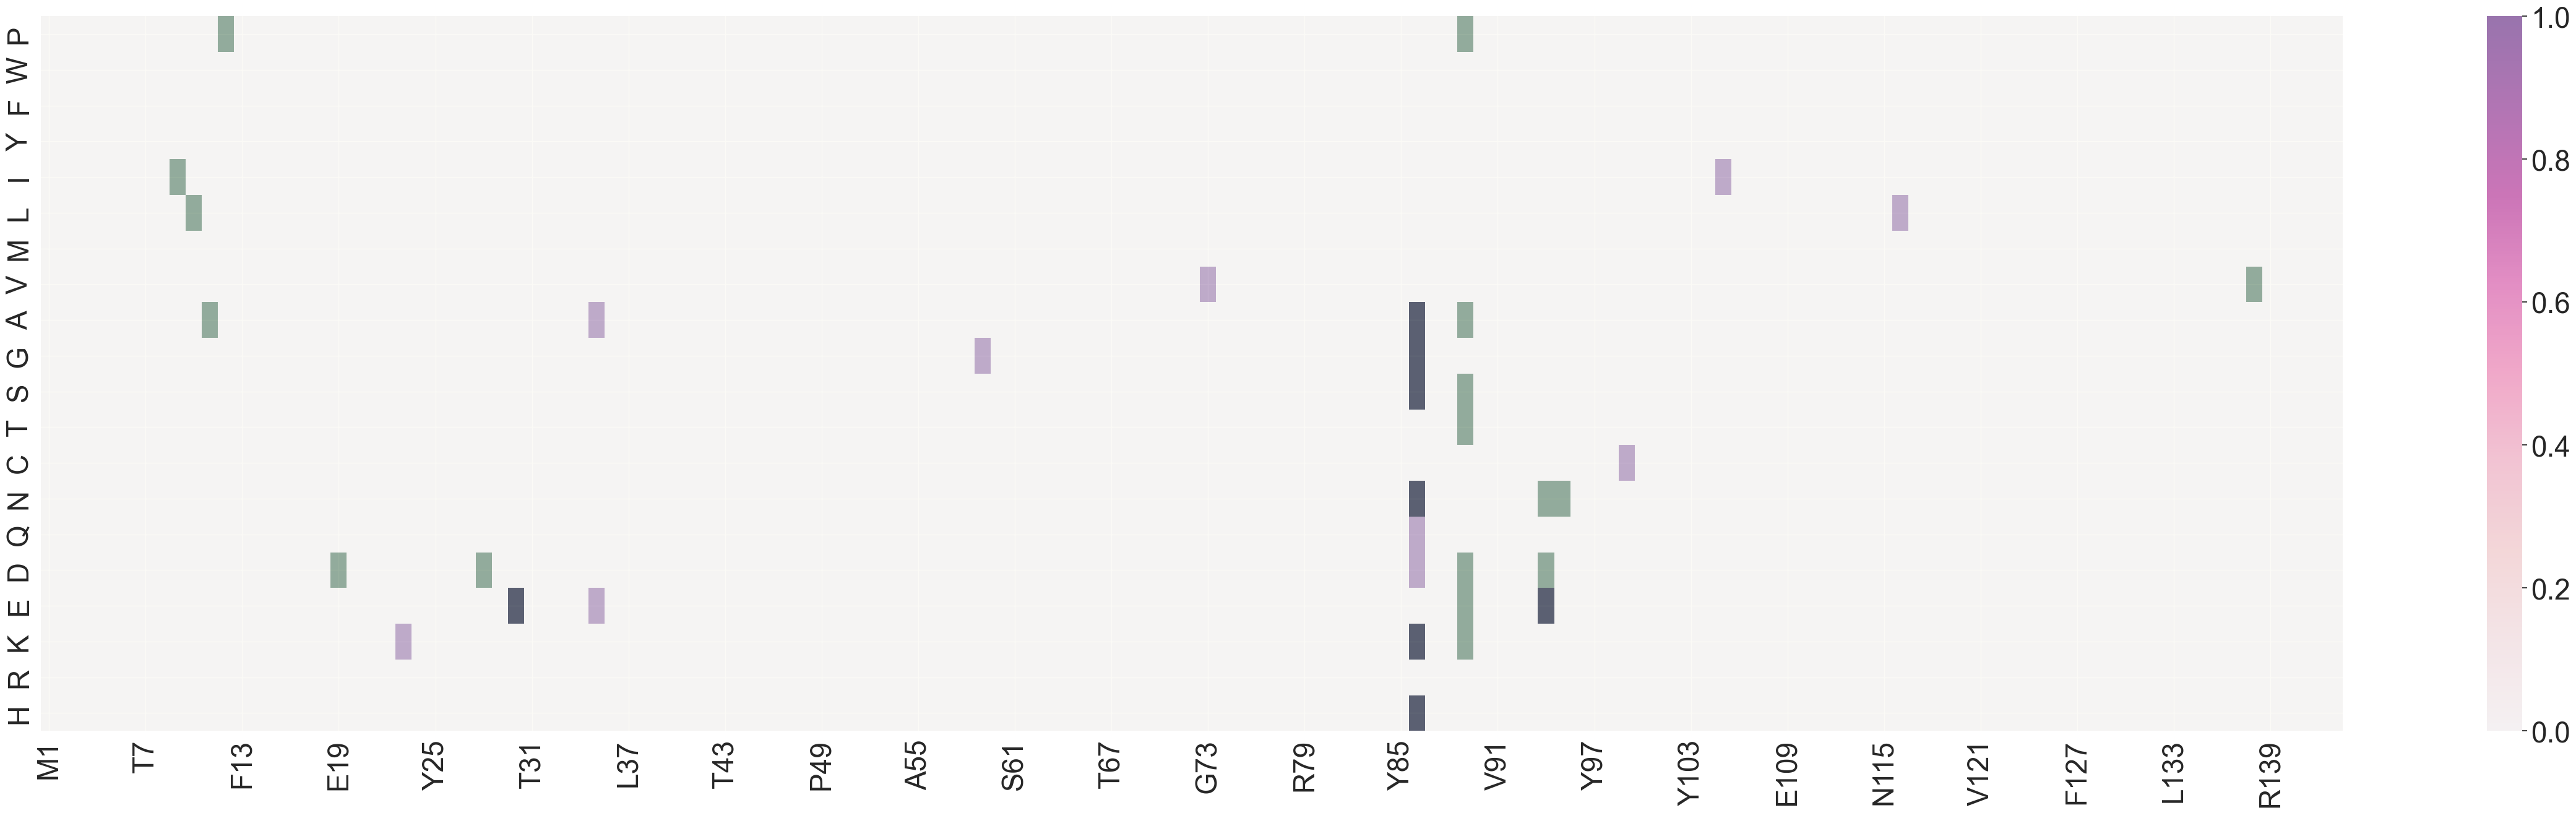

In [7]:
# figure generation

sns.set(font_scale=3)

# use all three datasets
two_df_L = L2+L3

# make csv output
two_df_L.to_csv('two_df_RbcL.csv')

fig, ax = plt.subplots(figsize=(60,15))

from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

colors = [(0, "white"), (1, "green")]
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)


# First heatmap
sns.heatmap(L2, cmap="RdPu", alpha=0.5, linecolor="Black", cbar=True, linewidths=0)

# Overlay second heatmap
sns.heatmap(L3, cmap="Greens", alpha=0.4, linecolor="Black", cbar=False, linewidths=0)


#set AA x-axis range
ax.set_xlim(0, 143)
#ax.set_xlim(250, 477)


# uncomment to save figure
#plt.savefig('two_preds_250915_1.png', dpi=300)

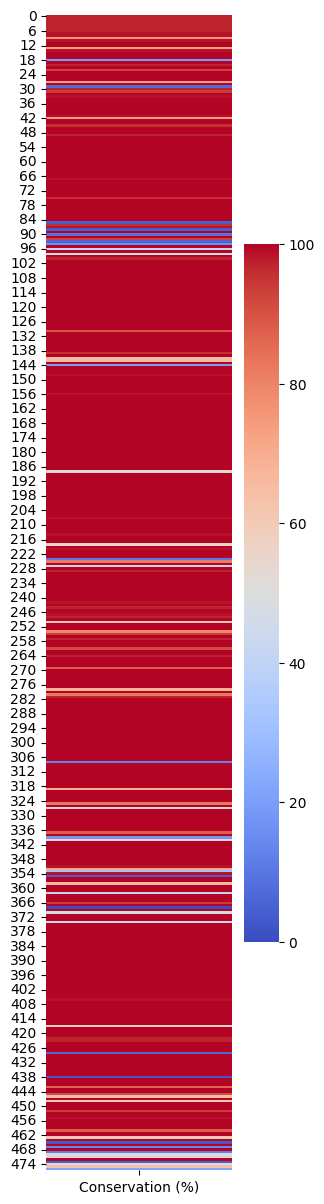

In [4]:
#plant conservation score bar

cons = pd.read_csv('/Users/juliemcdonald/Documents/Shoulders_lab/Rubisco_data/heatmap_testing/input_files/bouvier_conservation.csv')

plt.figure(figsize=(3, 15))

ax = sns.heatmap(cons, cmap = "coolwarm", )

# uncomment to save figure
#plt.savefig('bouvier_conservation.png', dpi=300)

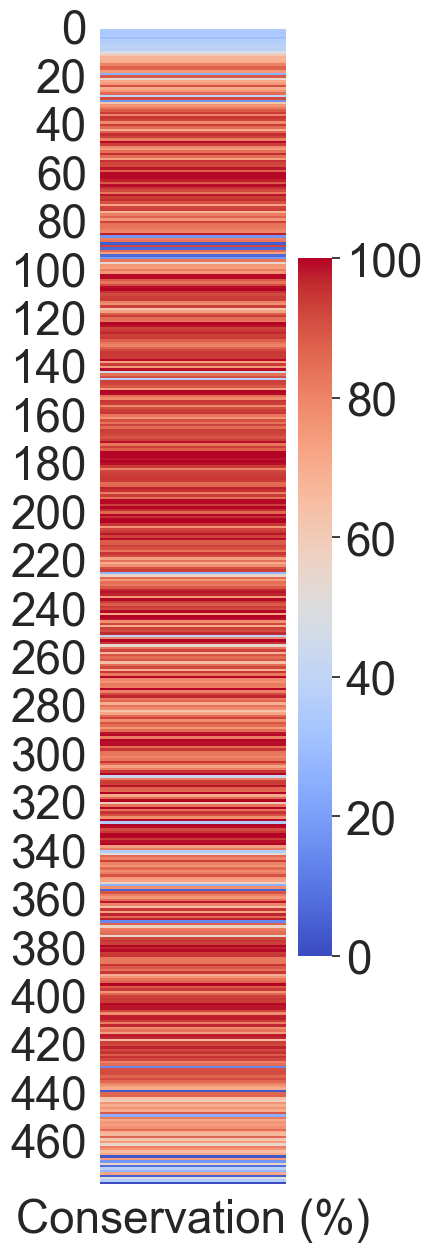

In [8]:
#all species conservation score bar

cons = pd.read_csv('/Users/juliemcdonald/Documents/Shoulders_lab/Rubisco_data/heatmap_testing/input_files/conservation.csv')

plt.figure(figsize=(3, 15))

ax = sns.heatmap(cons, cmap = "coolwarm", )

# uncomment to save figure
#plt.savefig('conservation.png', dpi=300)

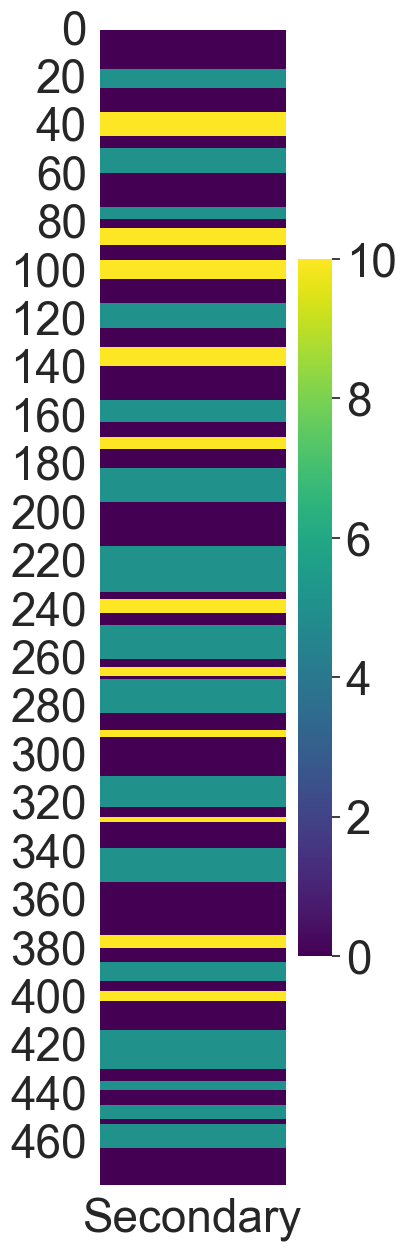

In [9]:
#secondary structure

cons = pd.read_csv('/Users/juliemcdonald/Documents/Shoulders_lab/Rubisco_data/heatmap_testing/input_files/secondary.csv')

plt.figure(figsize=(3, 15))

ax = sns.heatmap(cons, cmap = "viridis", )

# uncomment to save figure
# plt.savefig('Nt_secondary_struct.png', dpi=300)